In [138]:
from dotenv import load_dotenv
import os

load_dotenv()  # take environment variables from .env.

if os.environ['OPENAI_API_KEY']:
    print("Open API Key is set")
else:
    raise ValueError("OPENAI_API_KEY is not set in the environment variables.")

Open API Key is set


In [139]:
# taken from https://docs.langchain.com/oss/python/integrations/chat/openai - instantiation section
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage

llm = ChatOpenAI(model="gpt-5.4-nano-2026-03-17")

## **TOOLS**

### **Tavily**

In [140]:
import getpass
import os
from langchain_tavily import TavilySearch

if os.environ.get("TAVILY_API_KEY"):
    print("Tavily API Key is set")
else:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API key:\n")

@tool
def tavily_search(query:str) -> str:
    """This tool allows you to search the web for information related to the query."""
    tool = TavilySearch(
        max_results=5,
        topic="general",
        # include_answer=False,
        # include_raw_content=False,
        # include_images=False,
        # include_image_descriptions=False,
        # search_depth="basic",
        # time_range="day",
        # include_domains=None,
        # exclude_domains=None
    )
    return tool.invoke({"query": query})


Tavily API Key is set


## **EXA Search**

In [141]:
import getpass
import os

if os.environ.get("EXA_API_KEY"):
    print("Exa Search API Key is set")
else:
    os.environ["EXA_API_KEY"] = getpass.getpass("Exa API key:\n")

Exa Search API Key is set


In [142]:
from langchain_exa import ExaSearchResults

@tool
def exa_tool(query: str) -> str:
    """This tool allows you to search Exa for information related to the query."""
    # Initialize the ExaSearchResults tool
    search_tool = ExaSearchResults(exa_api_key=os.environ["EXA_API_KEY"])

    # Perform a search query
    search_results = search_tool._run(
        query,
        num_results=5,
        text_contents_options=True,
        highlights=True,
    )

    return search_results

# print("Search Results:", search_results)

## **Wikipedia Tools**

In [143]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
import wikipedia.wikipedia as wiki

@tool
def wiki_tool(query: str) -> str:
    """This tool searches the latest news on Wikipedia for the given query and returns the results."""
    # Avoid anonymous/default UA rate-limiting responses that break JSON parsing.
    wiki.USER_AGENT = "langgraphexploration/0.1 (local learning notebook)"
    wiki.API_URL = "https://en.wikipedia.org/w/api.php"

    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)


## **Arxiv Tools**

In [144]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
import arxiv

@tool
def arxiv_tool(query: str) -> str:
    """"This tool allows you to query the arXiv database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

    try:
        # Works with wrapper/library combinations that still expose Search.results().
        result = arxiv_query.invoke(query)
    except AttributeError as ex:
        # Fallback for arxiv>=4 where Search.results() was removed.
        if "results" not in str(ex):
            raise

        client = arxiv.Client()
        search = arxiv.Search(
            query=query,
            max_results=3,
            sort_by=arxiv.SortCriterion.SubmittedDate,
        )
        papers = []
        for paper in client.results(search):
            authors = ", ".join(author.name for author in paper.authors[:5])
            papers.append(
                f"Published: {paper.published.date()}\n"
                f"Title: {paper.title}\n"
                f"Authors: {authors}\n"
                f"Summary: {paper.summary[:500]}"
            )

        result = "\n\n".join(papers) if papers else "No papers found."

    return result


## **DuckDuckGo search tool**

In [145]:
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def search_duckduckgo(query: str) -> str:
    """This tool searches the latest news on DuckDuckGo for the given query and returns the results."""
    duckduckgo_search = DuckDuckGoSearchRun()
    return duckduckgo_search.invoke(query)

In [146]:
# search_duckduckgo.invoke("Who is the president of USA?")

In [147]:
# exa_tool.invoke("When was the last time the New York Knicks won the NBA Championship?")

## **Tools Binding**

In [148]:
tools = [exa_tool, wiki_tool, arxiv_tool, search_duckduckgo, tavily_search]
# tools = [search_duckduckgo]

llm_with_tools = llm.bind_tools(tools)
# response = llm_with_tools.invoke("What is the latest news on Indonesia?")
# response
# response.tool_calls

## **LangGraph creation**

### **Create Schema**

In [149]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages: List


### **Create Node Functions**

In [150]:
def llm_node(state: graph_schema) -> graph_schema:
    messages = state['messages']
    
    # Prompt template for the LLM to use tools to answer questions
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

    # LLM with tools to answer questions
    # llm_with_tools

    chain = prompt | llm_with_tools

    response = chain.invoke({"input": messages})

    # update the state with the new message
    state['messages'] = messages + [response]

    return state

In [151]:
def tool_node(state: graph_schema) -> graph_schema:
    messages = state['messages']
    
    # tools by name
    tools_by_name = {tool.name : tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with tool results
    state['messages'] = messages + tool_results

    return state

## **Create Conditional Edge Function**

In [152]:
def if_tool_call(state: graph_schema) -> str:
    last_message = state['messages'][-1]
    
    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

## **Create State Graph**

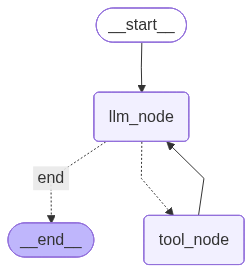

In [153]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges between nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

react_graph = graph.compile()

from IPython.display import Image, display
Image(react_graph.get_graph().draw_mermaid_png())

In [154]:
for chunk in react_graph.stream(
    {"messages": [HumanMessage(content="What is the latest news on AI?")]},
    stream_mode="updates"
):
    print(chunk)

{'llm_node': {'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 299, 'total_tokens': 396, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-E1vtg4WLCufqG5MByrAbV4CZ6G4nk', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f6669-1ce6-7383-b8f2-193a65ad07bb-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI'}, 'id': 'call_ue2fcnXE1yGbeEMLr7OlBGlv', 'type': 'tool_call'}, {'name': 'tavily_search', 'args': {'query': 'latest news artificial intelligence develo

In [155]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 299, 'total_tokens': 377, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-E1vtwH9aYZsA7A7lud72rXKRbiqiL', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f6669-58fd-7201-beb0-c42eb18e5f2d-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI'}, 'id': 'call_GQOnSE6iCZ4SYJi40RHwhiC6', 'type': 'tool_call'}, {'name': 'tavily_search', 'args': {'query': 'latest AI news'}, 'id': 'call_j6IiPDbK27hD4l66O78ENOf